#Assignment 5

## Zachary Fletcher

#Task 1

### Part A

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import statsmodels.api as sm

In [ ]:
game_data = pd.read_csv('https://raw.githubusercontent.com/matthewpecsok/4482_fall_2024/main/data/NA_sales_filtered.csv', encoding='latin-1')

### Part B

In [ ]:
game_data.head()

,Name,Platform,Genre,Rating,Critic_Score,Critic_Count,User_Score,User_Count,NA_Sales
0,Final Fantasy VII,PS,Role-Playing,T,92,20,91,1282,3.01
1,Final Fantasy X,PS2,Role-Playing,T,92,53,86,1056,2.91
2,The Sims 3,PC,Simulation,T,86,75,75,886,0.99
3,Final Fantasy VIII,PS,Role-Playing,T,90,24,85,644,2.28
4,Tekken 3,PS,Fighting,T,96,15,90,367,3.27


In [ ]:
game_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6345 entries, 0 to 6344
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Name          6345 non-null   object 
 1   Platform      6345 non-null   object 
 2   Genre         6345 non-null   object 
 3   Rating        6345 non-null   object 
 4   Critic_Score  6345 non-null   int64  
 5   Critic_Count  6345 non-null   int64  
 6   User_Score    6345 non-null   int64  
 7   User_Count    6345 non-null   int64  
 8   NA_Sales      6345 non-null   float64
dtypes: float64(1), int64(4), object(4)
memory usage: 446.3+ KB


In [ ]:
game_data.describe()

,Critic_Score,Critic_Count,User_Score,User_Count,NA_Sales
count,6345.000000,6345.000000,6345.000000,6345.000000,6345.000000
mean,69.819385,28.966745,70.765485,152.730969,0.354230
std,13.945811,19.098594,14.438432,545.962483,0.494404
min,13.000000,3.000000,5.000000,4.000000,0.010000
25%,61.000000,14.000000,64.000000,10.000000,0.080000
50%,72.000000,25.000000,74.000000,24.000000,0.170000
75%,80.000000,40.000000,81.000000,77.000000,0.410000
max,98.000000,113.000000,95.000000,10665.000000,3.490000


In [ ]:
game_data.isnull().sum()

,0
Name,0
Platform,0
Genre,0
Rating,0
Critic_Score,0
Critic_Count,0
User_Score,0
User_Count,0
NA_Sales,0


### Part C

In [ ]:
game_data = game_data.drop(columns=['Rating'])
game_data

,Name,Platform,Genre,Critic_Score,Critic_Count,User_Score,User_Count,NA_Sales
0,Final Fantasy VII,PS,Role-Playing,92,20,91,1282,3.01
1,Final Fantasy X,PS2,Role-Playing,92,53,86,1056,2.91
2,The Sims 3,PC,Simulation,86,75,75,886,0.99
3,Final Fantasy VIII,PS,Role-Playing,90,24,85,644,2.28
4,Tekken 3,PS,Fighting,96,15,90,367,3.27
...,...,...,...,...,...,...,...,...
6340,Toy Soldiers: War Chest,PS4,Action,62,19,76,61,0.06
6341,Toy Soldiers: War Chest,XOne,Action,60,14,83,50,0.05
6342,The Wolf Among Us,X360,Adventure,83,5,76,88,0.01
6343,Agatha Christie's The ABC Murders,XOne,Adventure,66,7,74,8,0.01


I decided to remove Rating, because it cannot be generalized outside the U.S., another country may rate the same game differently.

# Task 2

### Part A

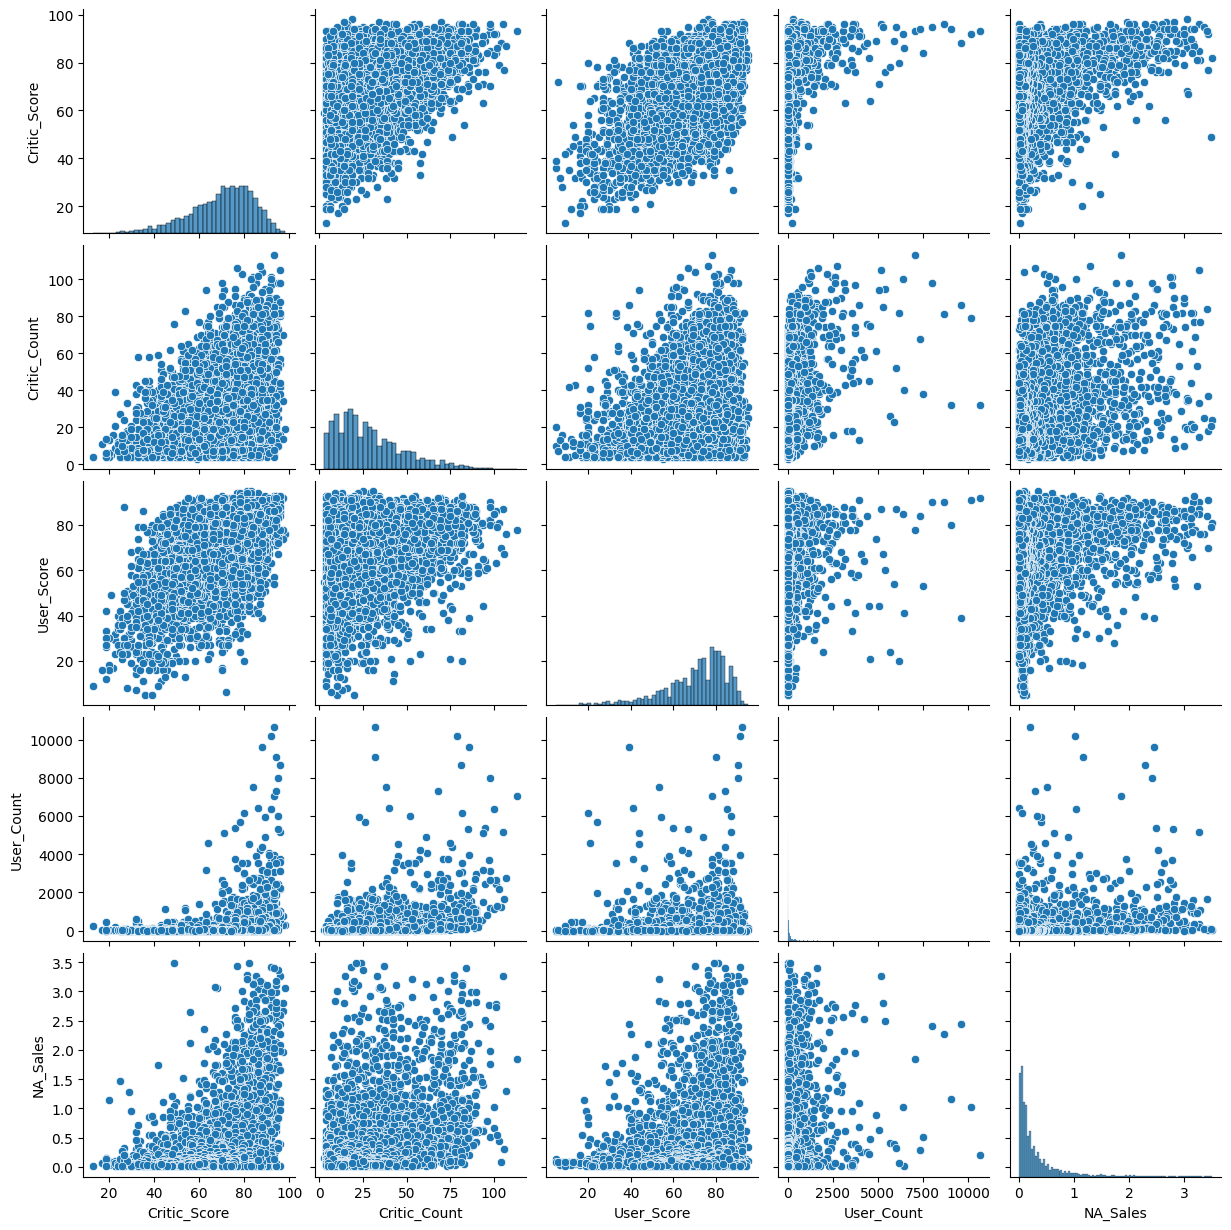

In [ ]:
sns.pairplot(game_data)

### Part B

In [ ]:
from sklearn.tree import DecisionTreeRegressor

reg_tree = DecisionTreeRegressor(random_state=42) # You can set a max_depth later
reg_tree.fit(X_train, y_train)

In [ ]:
game_corr = game_data[['Critic_Score', 'User_Score', 'Critic_Count', 'User_Count', 'NA_Sales']].corr()
game_corr

,Critic_Score,User_Score,Critic_Count,User_Count,NA_Sales
Critic_Score,1.000000,0.584548,0.390399,0.243688,0.352974
User_Score,0.584548,1.000000,0.192762,0.012398,0.145351
Critic_Count,0.390399,0.192762,1.000000,0.348060,0.343505
User_Count,0.243688,0.012398,0.348060,1.000000,0.268393
NA_Sales,0.352974,0.145351,0.343505,0.268393,1.000000


### Part C

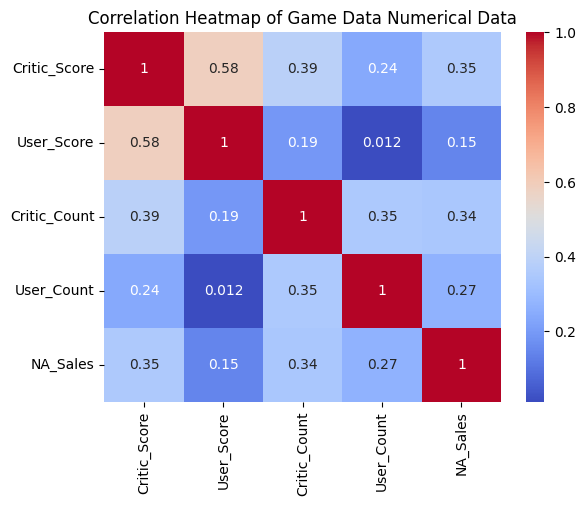

In [ ]:
sns.heatmap(game_corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Game Data Numerical Data')
plt.show()

### Part D

Strongest Positive correlation: user score and critic score

Strongest Negative Correlation: N/A. no negatively correlated variables.

Least Correlation: user count and user score


# Task 3

### Part A

Yes, you need to dummy encode the data considering that name, genre and platform are categorical data. Since regressiononly takes in numeric values, the model would not work properly without dummy encoding.

In [ ]:
game_data_enc = pd.get_dummies(game_data, columns=['Name', 'Genre', 'Platform'])
game_data_enc

,Critic_Score,Critic_Count,User_Score,User_Count,NA_Sales,Name_ Tales of Xillia 2,Name_.hack//Infection Part 1,Name_.hack//Mutation Part 2,Name_.hack//Outbreak Part 3,Name_007 Racing,...,Platform_PS2,Platform_PS3,Platform_PS4,Platform_PSP,Platform_PSV,Platform_Wii,Platform_WiiU,Platform_X360,Platform_XB,Platform_XOne
0,92,20,91,1282,3.01,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,92,53,86,1056,2.91,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
2,86,75,75,886,0.99,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,90,24,85,644,2.28,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,96,15,90,367,3.27,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6340,62,19,76,61,0.06,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
6341,60,14,83,50,0.05,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
6342,83,5,76,88,0.01,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
6343,66,7,74,8,0.01,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


### Part B

In [ ]:
y_target = game_data_enc.pop('NA_Sales')

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(game_data_enc, y_target, test_size=0.3, random_state=42)

### Part C

In [ ]:
X_test.info()
X_test.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 1904 entries, 730 to 3555
Columns: 4120 entries, Critic_Score to Platform_XOne
dtypes: bool(4116), int64(4)
memory usage: 7.5 MB


,Critic_Score,Critic_Count,User_Score,User_Count
count,1904.000000,1904.000000,1904.000000,1904.000000
mean,69.690651,28.623950,70.707983,162.871849
std,13.788676,19.027523,14.501375,607.677725
min,19.000000,4.000000,5.000000,4.000000
25%,61.000000,14.000000,63.000000,10.000000
50%,71.000000,24.000000,74.000000,24.000000
75%,80.000000,39.000000,81.000000,72.000000
max,96.000000,113.000000,95.000000,9073.000000


In [ ]:
X_train.info()
X_train.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 4441 entries, 334 to 860
Columns: 4120 entries, Critic_Score to Platform_XOne
dtypes: bool(4116), int64(4)
memory usage: 17.6 MB


,Critic_Score,Critic_Count,User_Score,User_Count
count,4441.000000,4441.000000,4441.000000,4441.000000
mean,69.874578,29.113713,70.790137,148.383247
std,14.013822,19.129240,14.412929,517.265687
min,13.000000,3.000000,7.000000,4.000000
25%,62.000000,14.000000,64.000000,10.000000
50%,72.000000,25.000000,74.000000,25.000000
75%,80.000000,40.000000,81.000000,80.000000
max,98.000000,107.000000,95.000000,10665.000000


In [ ]:
y_test.info()
y_test.describe()

<class 'pandas.core.series.Series'>
Index: 1904 entries, 730 to 3555
Series name: NA_Sales
Non-Null Count  Dtype  
--------------  -----  
1904 non-null   float64
dtypes: float64(1)
memory usage: 29.8 KB


,NA_Sales
count,1904.000000
mean,0.349884
std,0.481975
min,0.010000
25%,0.070000
50%,0.170000
75%,0.410000
max,3.430000


In [ ]:
y_train.info()
y_train.describe()

<class 'pandas.core.series.Series'>
Index: 4441 entries, 334 to 860
Series name: NA_Sales
Non-Null Count  Dtype  
--------------  -----  
4441 non-null   float64
dtypes: float64(1)
memory usage: 69.4 KB


,NA_Sales
count,4441.000000
mean,0.356093
std,0.499680
min,0.010000
25%,0.080000
50%,0.170000
75%,0.410000
max,3.490000


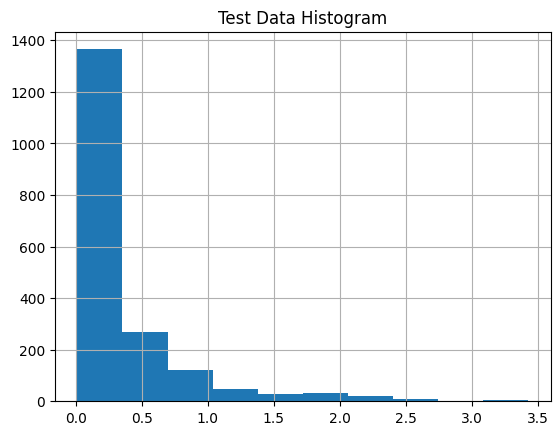

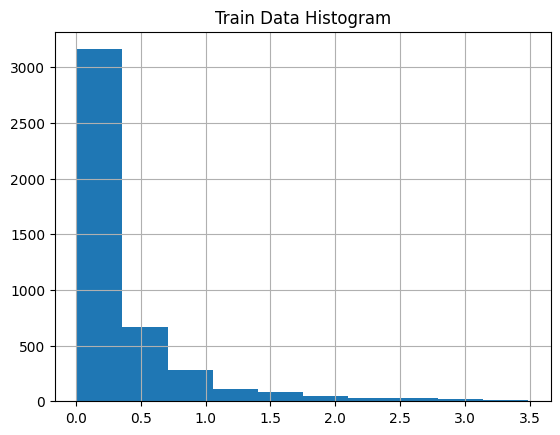

In [ ]:
y_test.hist()
plt.title('Test Data Histogram')
plt.show()

y_train.hist()
plt.title('Train Data Histogram')
plt.show()

# Task 4

### Part A and B

In [ ]:
reg_train = LinearRegression()
reg_train.fit(X_train, y_train)

LinearRegression()

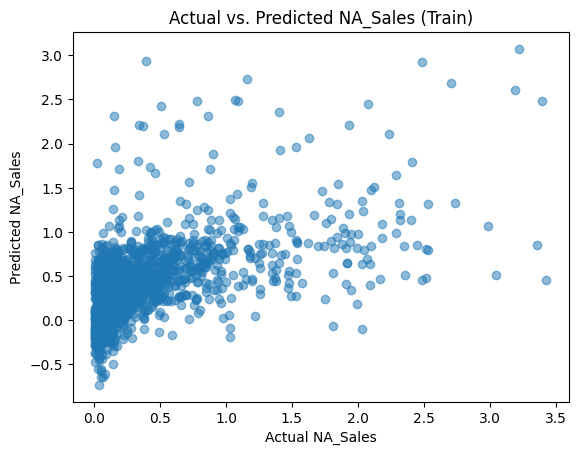

In [ ]:
y_pred_train = reg_train.predict(X_test)

plt.scatter(y_test, y_pred_train, alpha=0.5)
plt.xlabel("Actual NA_Sales")
plt.ylabel("Predicted NA_Sales")
plt.title("Actual vs. Predicted NA_Sales (Train)")
plt.show()

In [ ]:
reg_test = LinearRegression()
reg_test.fit(X_test, y_test)

LinearRegression()

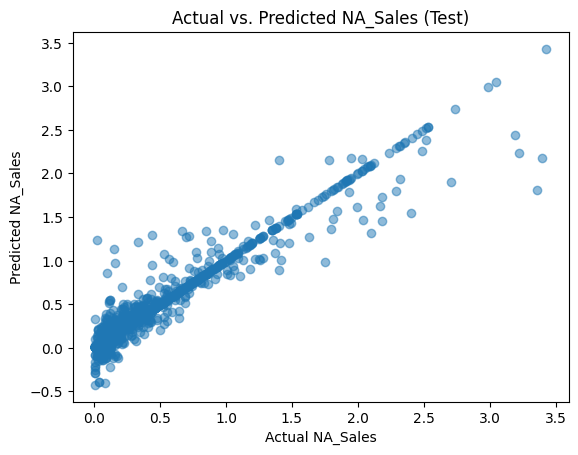

In [ ]:
y_pred_test = reg_test.predict(X_test)

plt.scatter(y_test, y_pred_test, alpha=0.5)
plt.xlabel("Actual NA_Sales")
plt.ylabel("Predicted NA_Sales")
plt.title("Actual vs. Predicted NA_Sales (Test)")
plt.show()

### Part C

In [ ]:
# R^2
print('Testing R^2:', reg_test.score(X_test, y_test))
print('Training R^2:', reg_train.score(X_train, y_train))

Testing R^2: 0.9345748585809965
Training R^2: 0.9019006841634397


In [ ]:
# Coefs
pd.DataFrame({'Training Feat': X_train.columns, 'Coef': reg_train.coef_})

,Testing Feat,Coef
0,Critic_Score,0.008767
1,Critic_Count,0.006991
2,User_Score,-0.000893
3,User_Count,0.000086
4,Name_ Tales of Xillia 2,-0.230430
...,...,...
4115,Platform_Wii,0.272237
4116,Platform_WiiU,-0.450691
4117,Platform_X360,0.136850
4118,Platform_XB,-0.122596


In [ ]:
#Coefs
pd.DataFrame({'Testing Feat': X_test.columns, 'Coef': reg_test.coef_})

,Testing Feat,Coef
0,Critic_Score,0.008767
1,Critic_Count,0.006991
2,User_Score,-0.000893
3,User_Count,0.000086
4,Name_ Tales of Xillia 2,-0.230430
...,...,...
4115,Platform_Wii,0.272237
4116,Platform_WiiU,-0.450691
4117,Platform_X360,0.136850
4118,Platform_XB,-0.122596


# Task 5

In [ ]:
# transform nonlinear variable by squaring it
game_data_enc['Critic_Score'] = game_data_enc['Critic_Score'] ** 2

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(game_data_enc, y_target, test_size=0.3, random_state=42)

In [ ]:
reg_train = LinearRegression()
reg_train.fit(X_train, y_train)

LinearRegression()

In [ ]:
reg_test = LinearRegression()
reg_test.fit(X_test, y_test)

LinearRegression()

In [ ]:
# R^2
print('Testing R^2:', reg_test.score(X_test, y_test))
print('Training R^2:', reg_train.score(X_train, y_train))

Testing R^2: 0.9347641645967726
Training R^2: 0.903183783398874


In [ ]:
# P value
X_train_sm_new = sm.add_constant(X_train)

for col in X_train_sm_new.columns:
    if X_train_sm_new[col].dtype == 'bool':
        X_train_sm_new[col] = X_train_sm_new[col].astype(int)

new_model_sm = sm.OLS(y_train, X_train_sm_new).fit()

print(new_model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:               NA_Sales   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.651
Method:                 Least Squares   F-statistic:                     3.575
Date:                Wed, 24 Sep 2025   Prob (F-statistic):          4.56e-128
Time:                        05:10:11   Log-Likelihood:                 1964.8
No. Observations:                4441   AIC:                             2492.
Df Residuals:                    1230   BIC:                         2.304e+04
Df Model:                        3210                                         
Covariance Type:            nonrobust                                         
                                                                                   coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------

In [ ]:
!jupyter nbconvert --to html "/content/A5_Fletcher_Zachary (3).ipynb"

[NbConvertApp] Converting notebook /content/A5_Fletcher_Zachary (3).ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 6 image(s).
[NbConvertApp] Writing 2024155 bytes to /content/A5_Fletcher_Zachary (3).html
